# Decision Tree
- Regression
- Classification

- make up
   - node
   - edge
   - root node
   - spilt node
   - leaf node

  
    

## Decision Criteria

- Classification : IG, GINI Impurity

> Entropy : means uncertainty.(bits)
- $ H(X) = - \sum_{i=1}^{n}{ P(x_{i}) log_{2} P(x_{i})} $

> IF(Information Gain) : Entropy calculation of parent nodes and child nodes.
Select the decision boundary in the direction of lowering entropy.
in other words. To maximize information gain
- $ IG = Entropy_{parent} - \sum {\frac {N_{child}}{N_{total}} Entropy_{child}} $

> Gini Impurity : Evaluate the imbalance of class distribution that exists in the data
- $ Gini(S) = 1 - \sum_{i=1}^{n}{p_{i}^{2}} $
  - $ p_{i} $ : The probability that the i
   class appears in the data set

     - "0" : All data belongs to one class. The state of highest purity.
     
     - "1" : A state in which data from all classes are evenly mixed. Highest impurity.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

seed = 1234
np.random.seed(seed)

In [5]:
# creates data
X, y = make_classification(n_samples=100,
                           n_features=2,
                           n_informative=2,
                           n_redundant=0,
                           n_clusters_per_class=1,
                           n_classes=3,
                           random_state=1)

X, X_test, y, y_test = train_test_split(
    X, y, test_size=0.3)



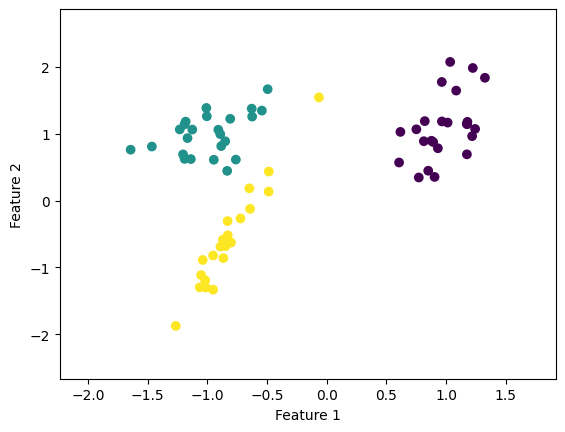

In [7]:
# plot
plt.scatter(X[:, 0], X[:, 1], c=y)\

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.margins(0.2)

In [8]:
# IG
dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3, min_samples_split=3)

dt_entropy.fit(X, y)


# Gini
dt_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3, min_samples_split=3)

dt_gini.fit(X, y)





DecisionTreeClassifier(max_depth=3, min_samples_split=3)

Text(0.5, 1.0, 'Decision Tree using Entropy')

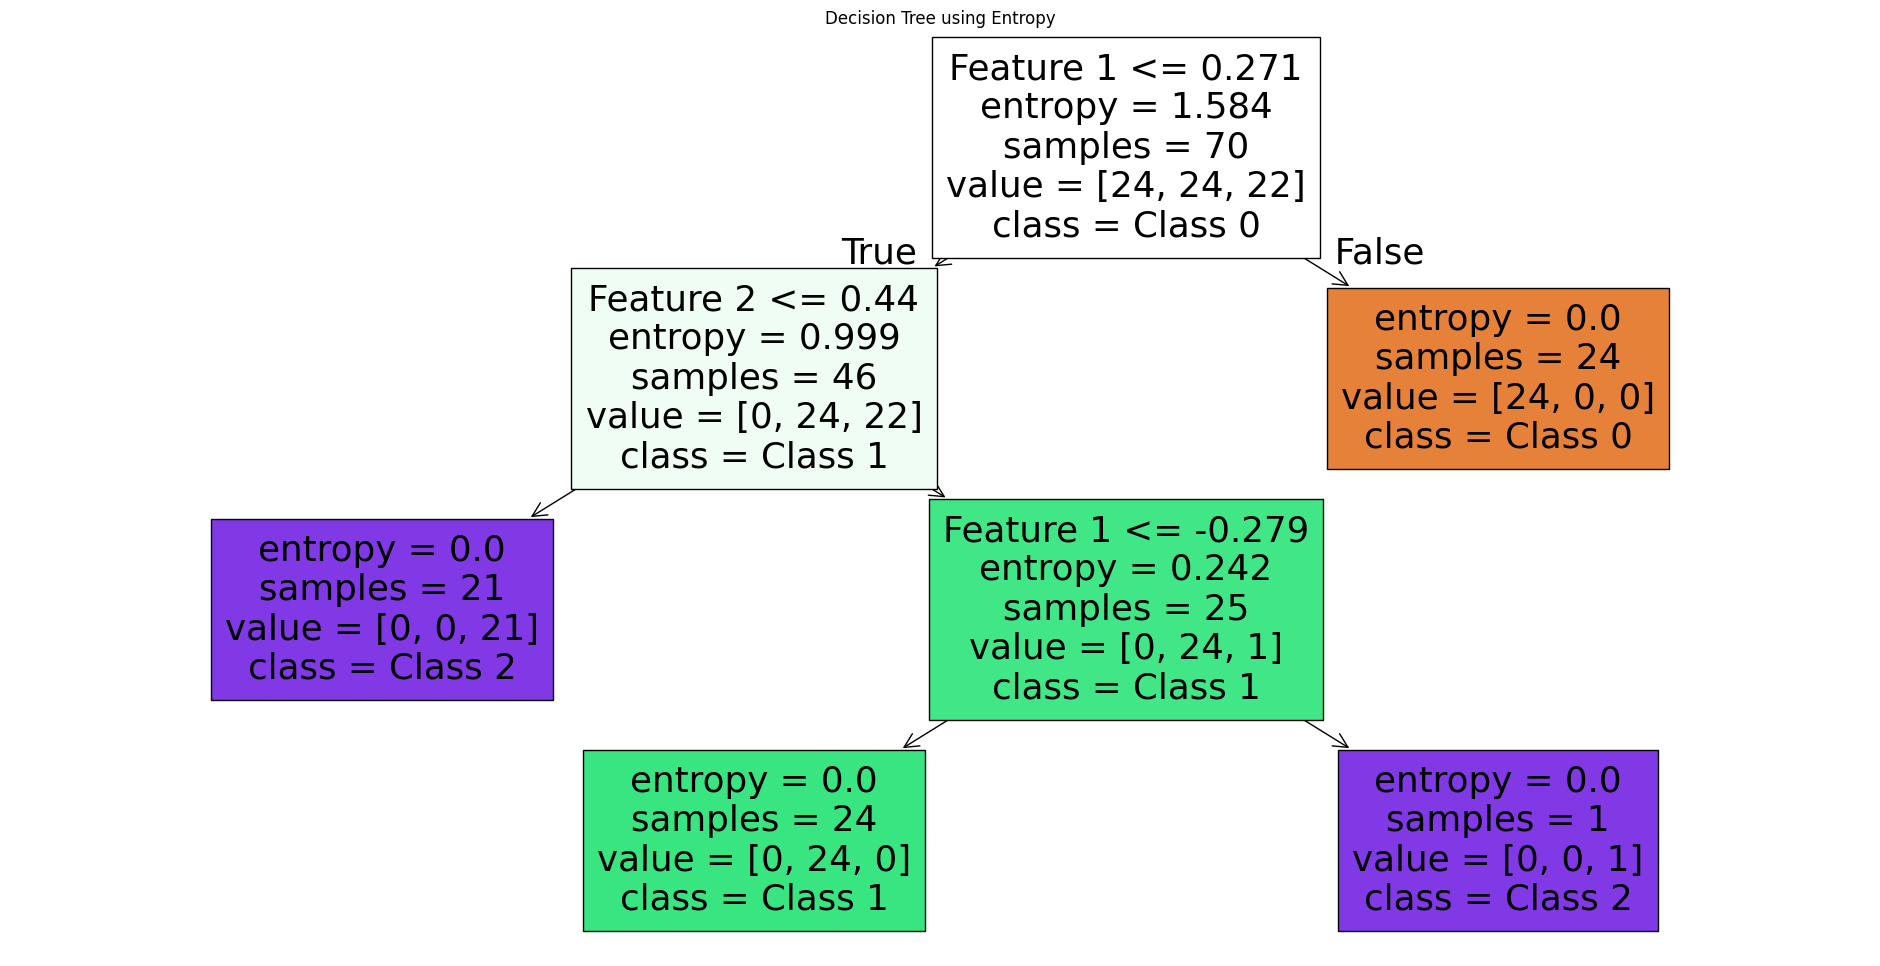

In [11]:
# find structure for DT
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 12))
plot_tree(dt_entropy, filled=True,
          feature_names=["Feature 1", "Feature 2"],
          class_names=["Class 0", "Class 1", "Class 2"])
plt.title("Decision Tree using Entropy")



Text(0.5, 1.0, 'Decision Tree using Gini')

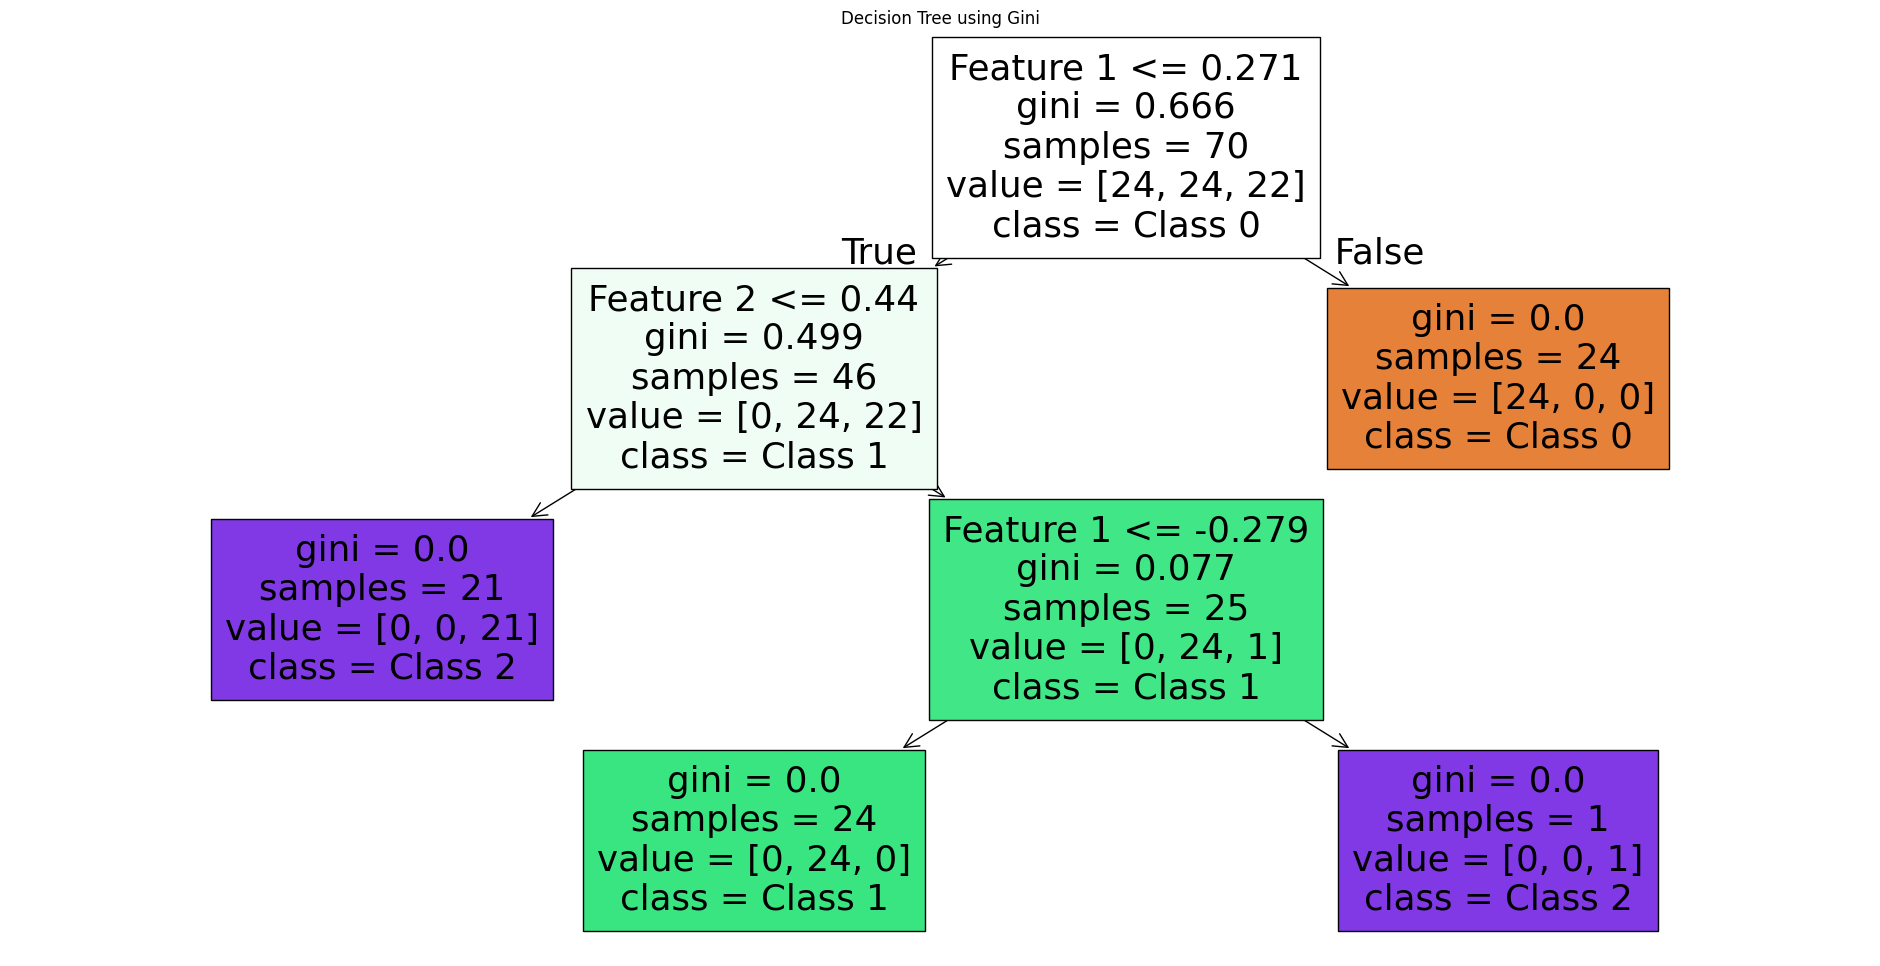

In [12]:
plt.figure(figsize=(24, 12))
plot_tree(dt_gini, filled=True,
          feature_names=["Feature 1", "Feature 2"],
          class_names=["Class 0", "Class 1", "Class 2"])
plt.title("Decision Tree using Gini")


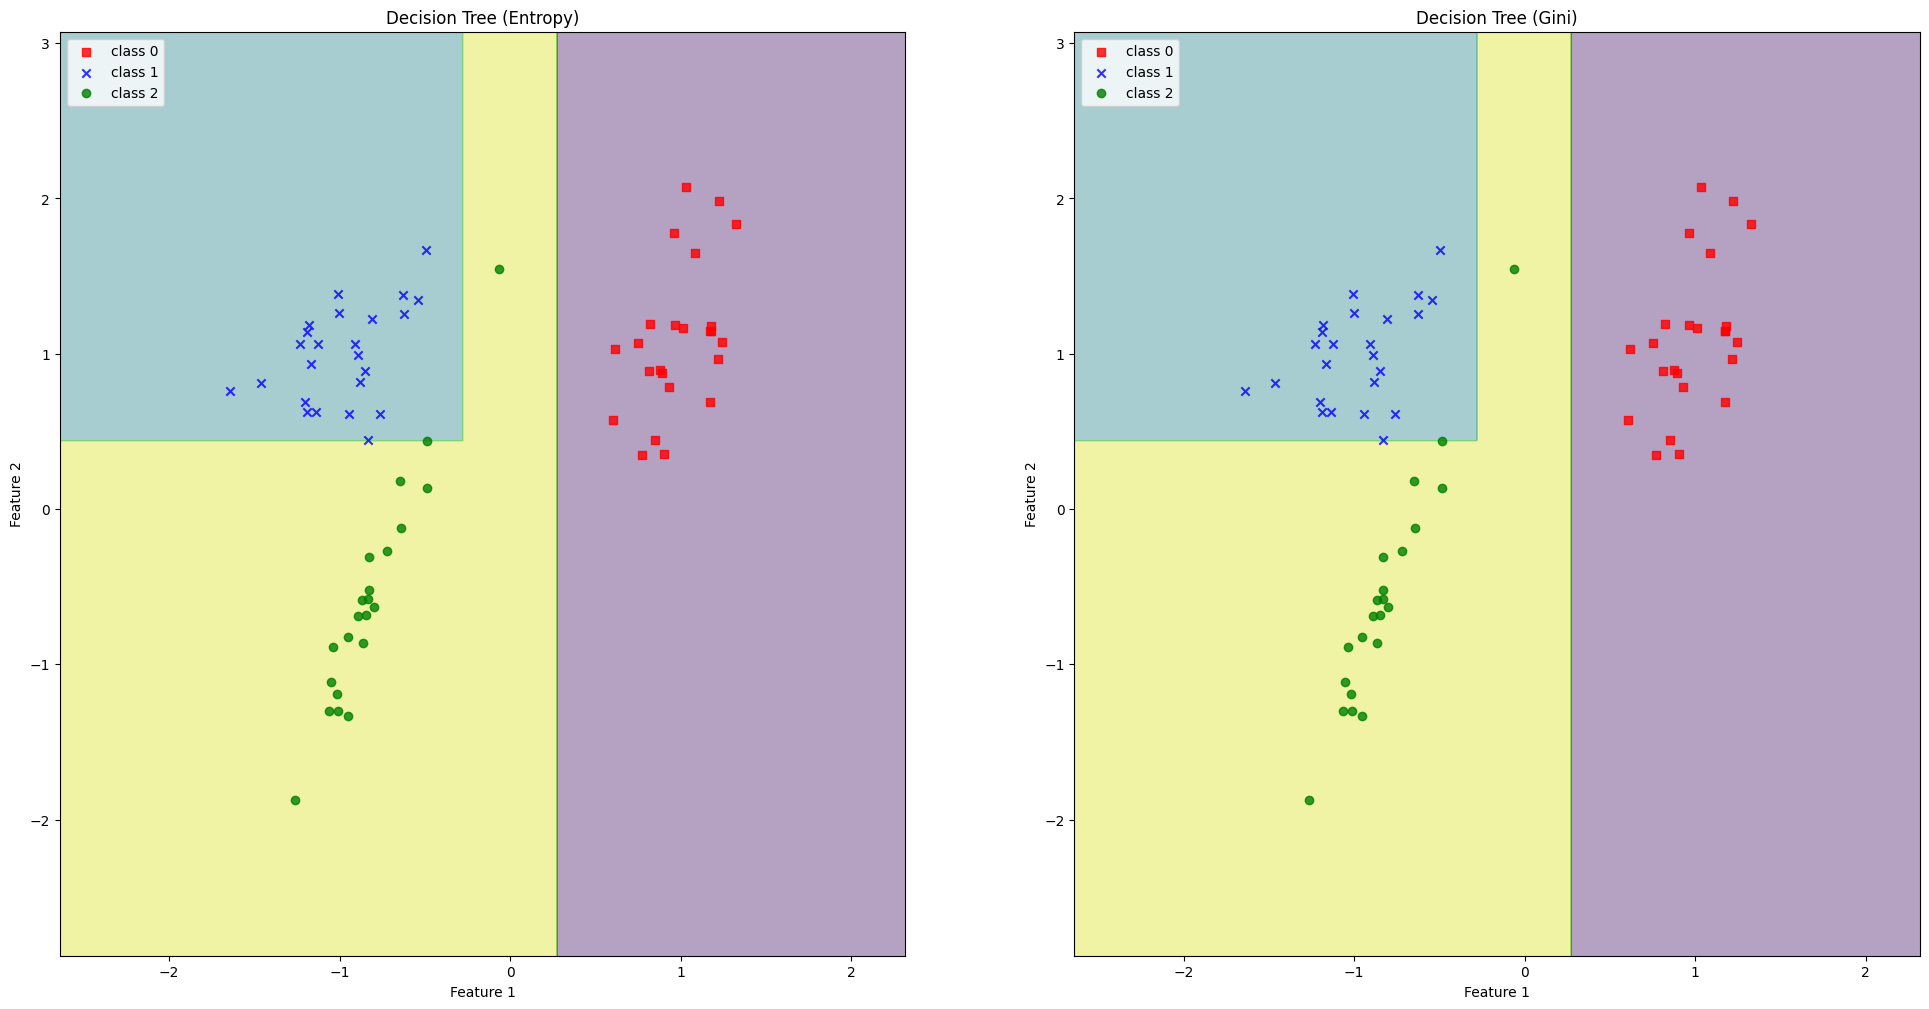

In [15]:
# plot boundary

def plot_decision_boundaries(X, y, model, title):
  markers = ('s', 'x', 'o')
  colors = ('red', 'blue', 'green')

  x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.01),
                         np.arange(x2_min, x2_max, 0.01))

  Z = model.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
  Z = Z.reshape(xx1.shape)

  plt.contourf(xx1, xx2, Z, alpha=0.4)

  for idx, cl in enumerate(np.unique(y)):
    plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                alpha=0.8, c=colors[idx],
                marker=markers[idx], label=f'class {cl}')

  plt.xlabel('Feature 1')
  plt.ylabel('Feature 2')
  plt.legend(loc='upper left')
  plt.title(title)


plt.figure(figsize=(24, 12))

plt.subplot(1, 2, 1)
plot_decision_boundaries(X, y, dt_entropy, "Decision Tree (Entropy)")

plt.subplot(1, 2, 2)
plot_decision_boundaries(X, y, dt_gini, "Decision Tree (Gini)"
)


Accuracy on Entropy : 96.67 %
Accuracy on Gini : 96.67 %


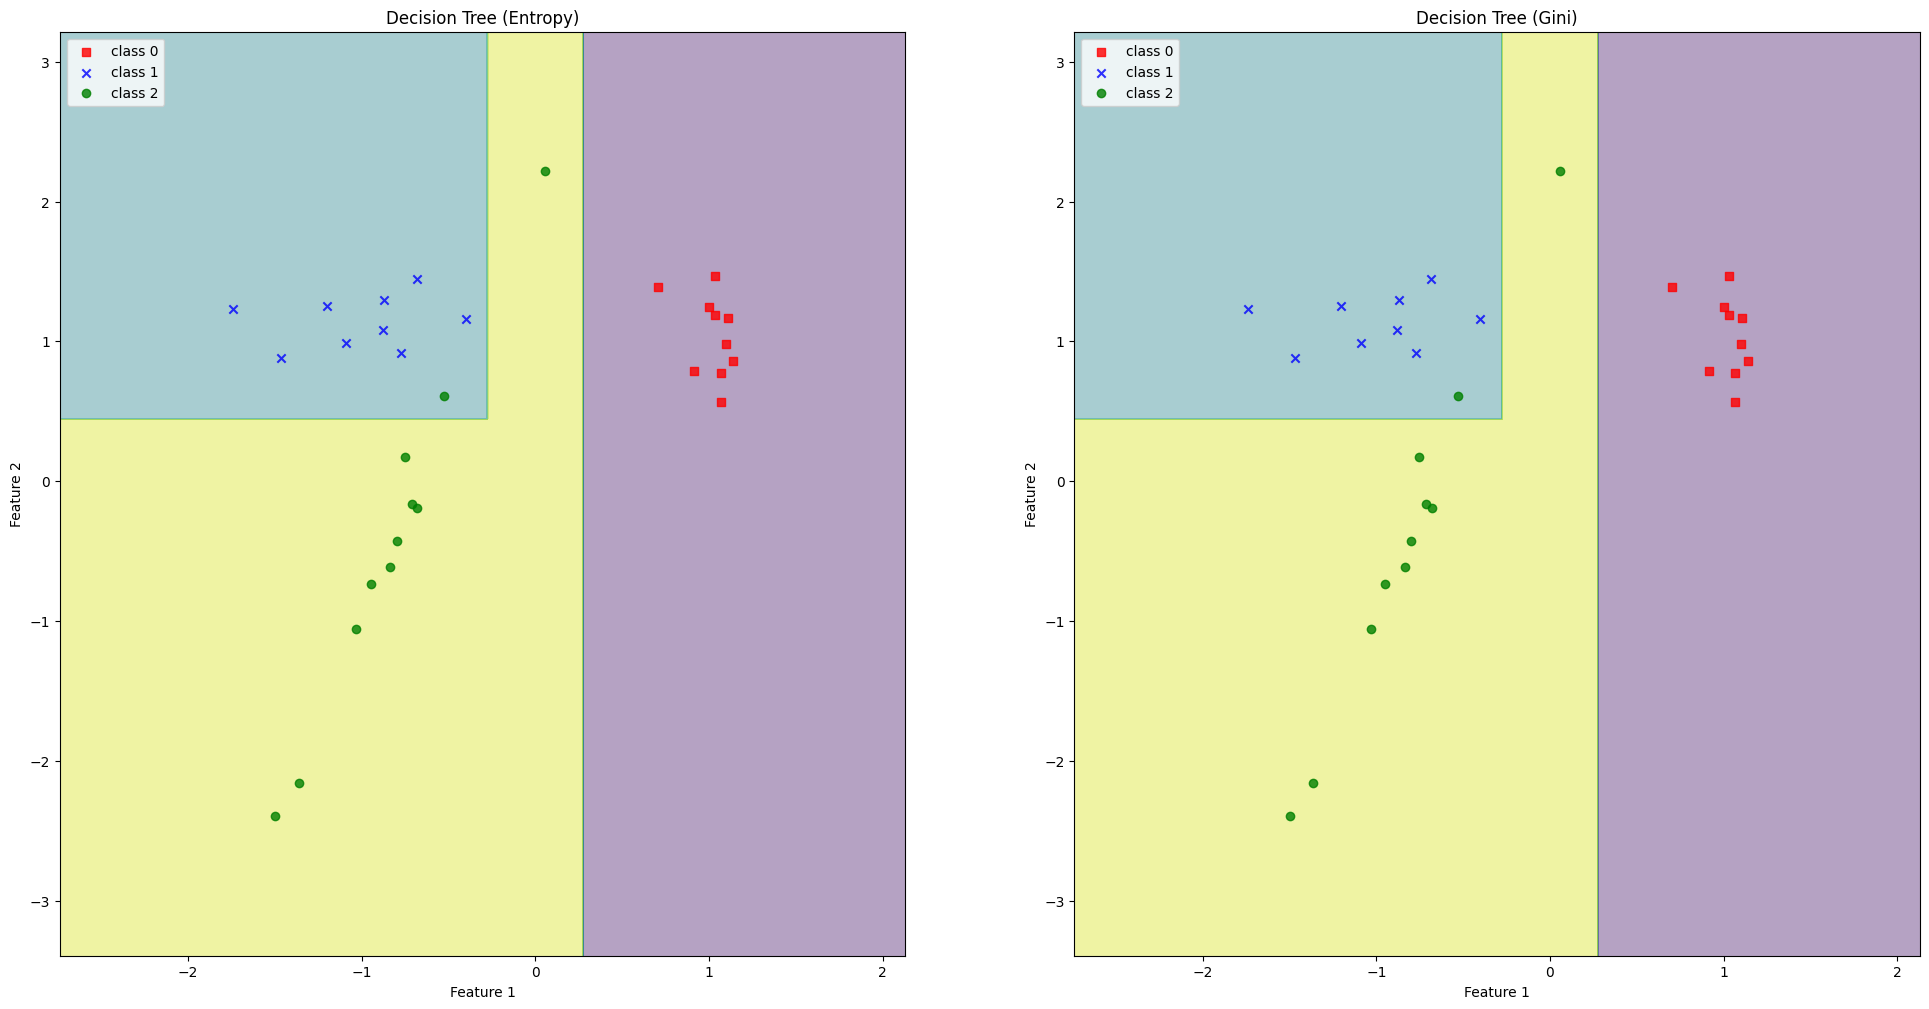

In [16]:
# test

y_pred = dt_entropy.predict(X_test)
acc = (y_pred == y_test).sum() / len(y_test)
print(f"Accuracy on Entropy : {acc*100:.2f} %")

y_pred = dt_gini.predict(X_test)
acc = (y_pred == y_test).sum() / len(y_test)
print(f"Accuracy on Gini : {acc*100:.2f} %")

plt.figure(figsize=(24, 12))

plt.subplot(1, 2, 1)
plot_decision_boundaries(X_test, y_test, dt_entropy,
                         "Decision Tree (Entropy)")

plt.subplot(1, 2, 2)
plot_decision_boundaries(X_test, y_test, dt_gini,
                         "Decision Tree (Gini)")



## Decision Criteria

- Regression : MSE

In [28]:
# makes data
w0 = 2.3
w1 = 1
num_data = 100
noise = np.random.normal(0, 3, num_data)

x = np.linspace(0, 5, num_data)
y = w0 + w1 * (x**2) + noise

X = x.reshape(-1, 1)

# min MSE
from sklearn.tree import DecisionTreeRegressor
dt_mse_reg = DecisionTreeRegressor(max_depth=3)
dt_mse_reg.fit(X, y)


DecisionTreeRegressor(max_depth=3)

Text(0.5, 1.0, 'Decision Tree using MSE')

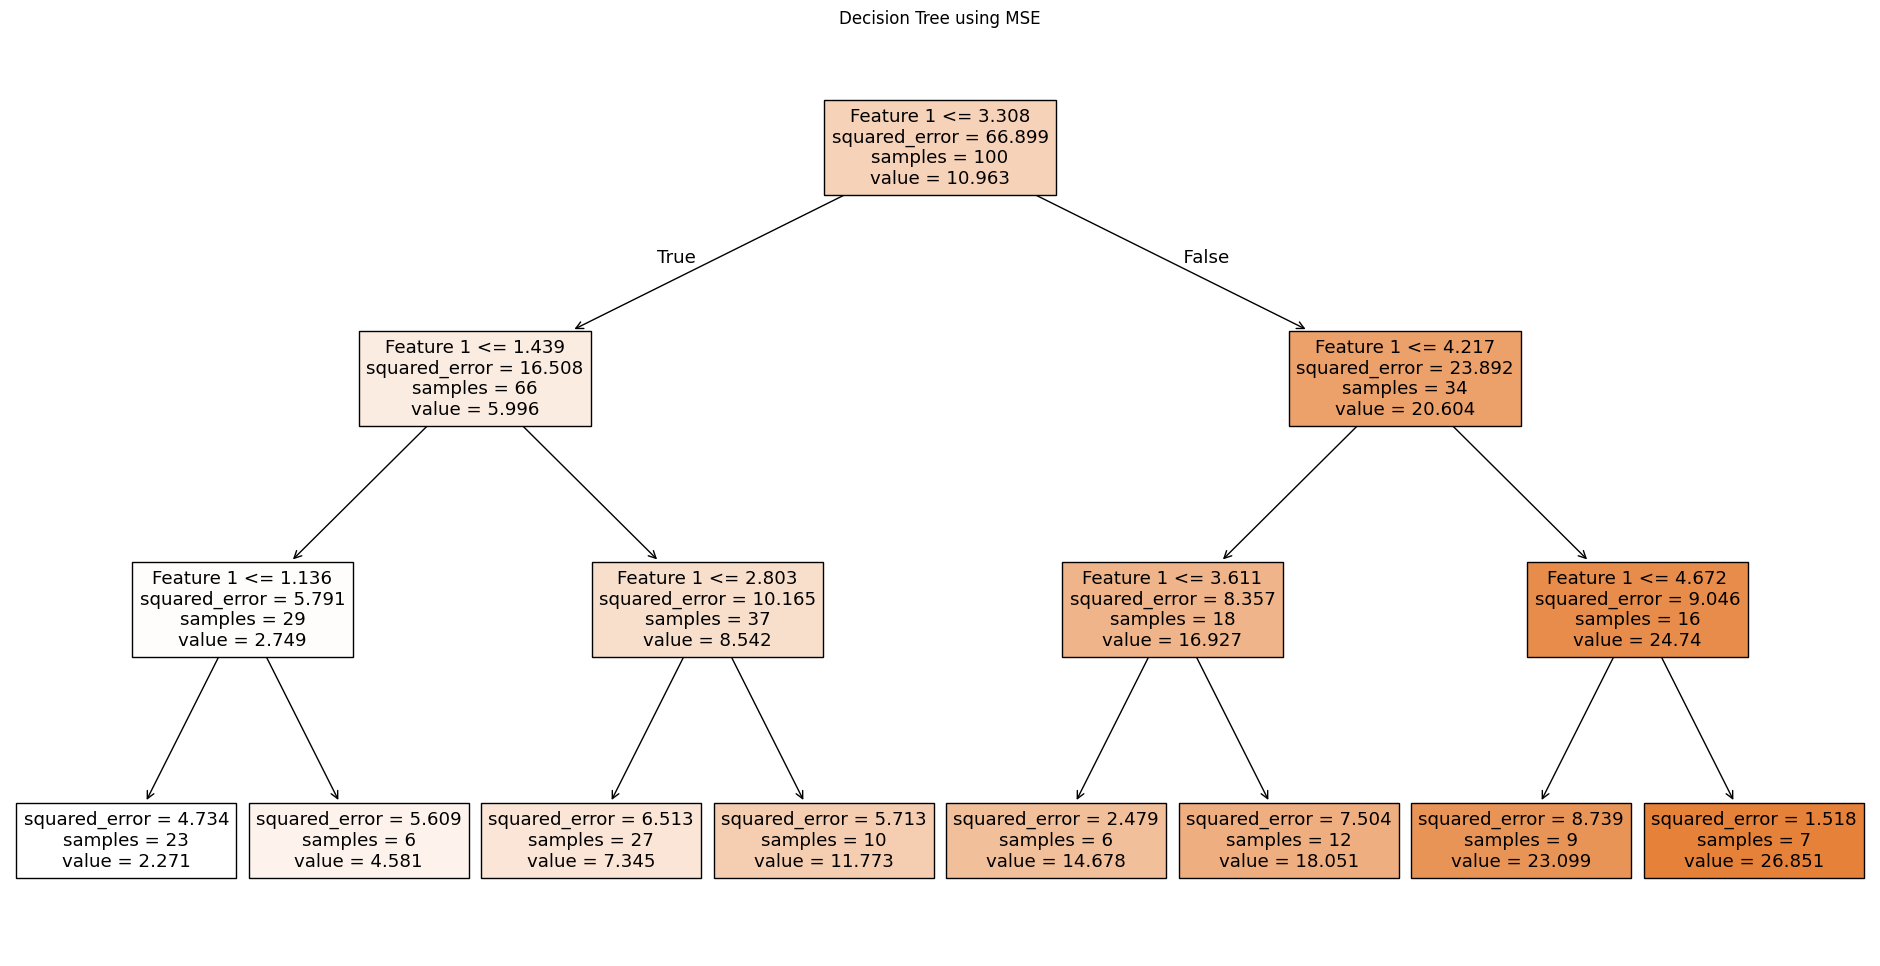

In [29]:
plt.figure(figsize=(24, 12))
plot_tree(dt_mse_reg, filled=True,
          feature_names=["Feature 1", "Feature 2"])
plt.title("Decision Tree using MSE")

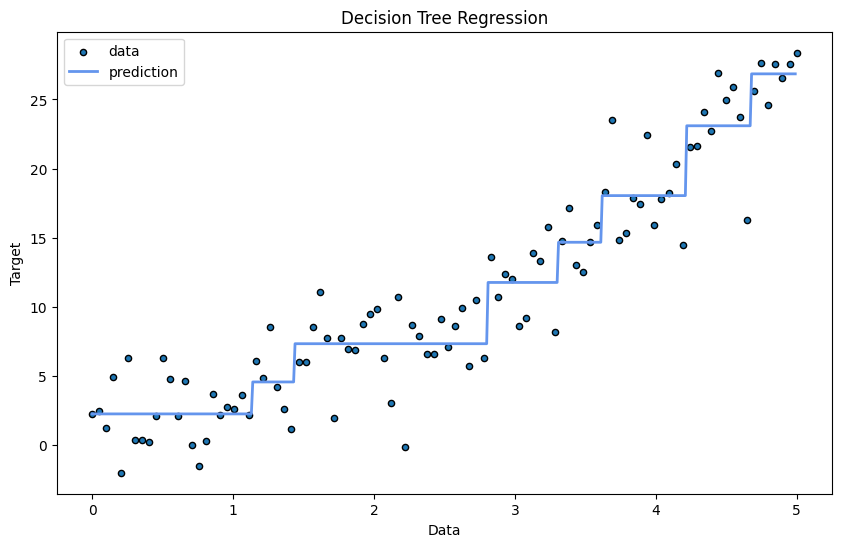

In [30]:
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_pred = dt_mse_reg.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=20,
            edgecolor="black", label="data")
plt.plot(X_test, y_pred, color="cornflowerblue",
         label="prediction", linewidth=2)

plt.xlabel("Data")
plt.ylabel("Target")
plt.title("Decision Tree Regression")
plt.legend()

# Tree Merits
- Easy to interpret
- Convenient to use
- good performance
- Insensitive to scaling

# Tree Demerits
- Split data in a direction perpendicular to the axis
  - If the boundary is rotated, a stepped boundary is created
- Very sensitive to noise
- Overfitting may occur